In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf

import matplotlib.pyplot as plt

In [26]:
df_train = pd.read_csv("train.csv")
df_train = df_train.drop('Id', axis=1)
df_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Data Exploration

In [27]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [28]:
df_train.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


C:\Users\user\AppData\Local\Temp\ipykernel_20820\3763950520.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['SalePrice'], color='g', bins=100, hist_kws={'alpha': 0.4});


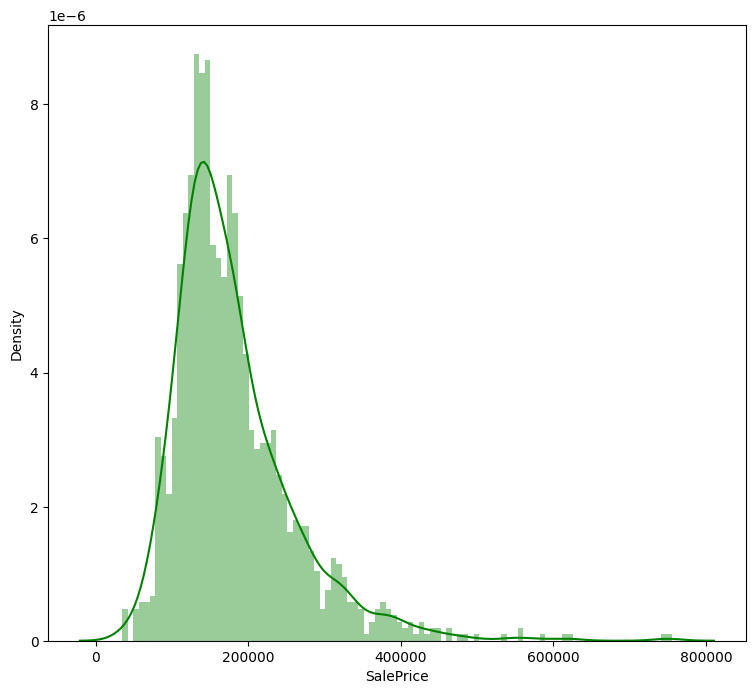

In [29]:
plt.figure(figsize=(9, 8))
sns.distplot(df_train['SalePrice'], color='g', bins=100, hist_kws={'alpha': 0.4});

In [30]:
# check data types
list(set(df_train.dtypes.tolist()))

df_quant = df_train.select_dtypes(include=['int64', 'float64'])
print("Quantitative (Numerical) Columns:")
df_quant.head()

Quantitative (Numerical) Columns:


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


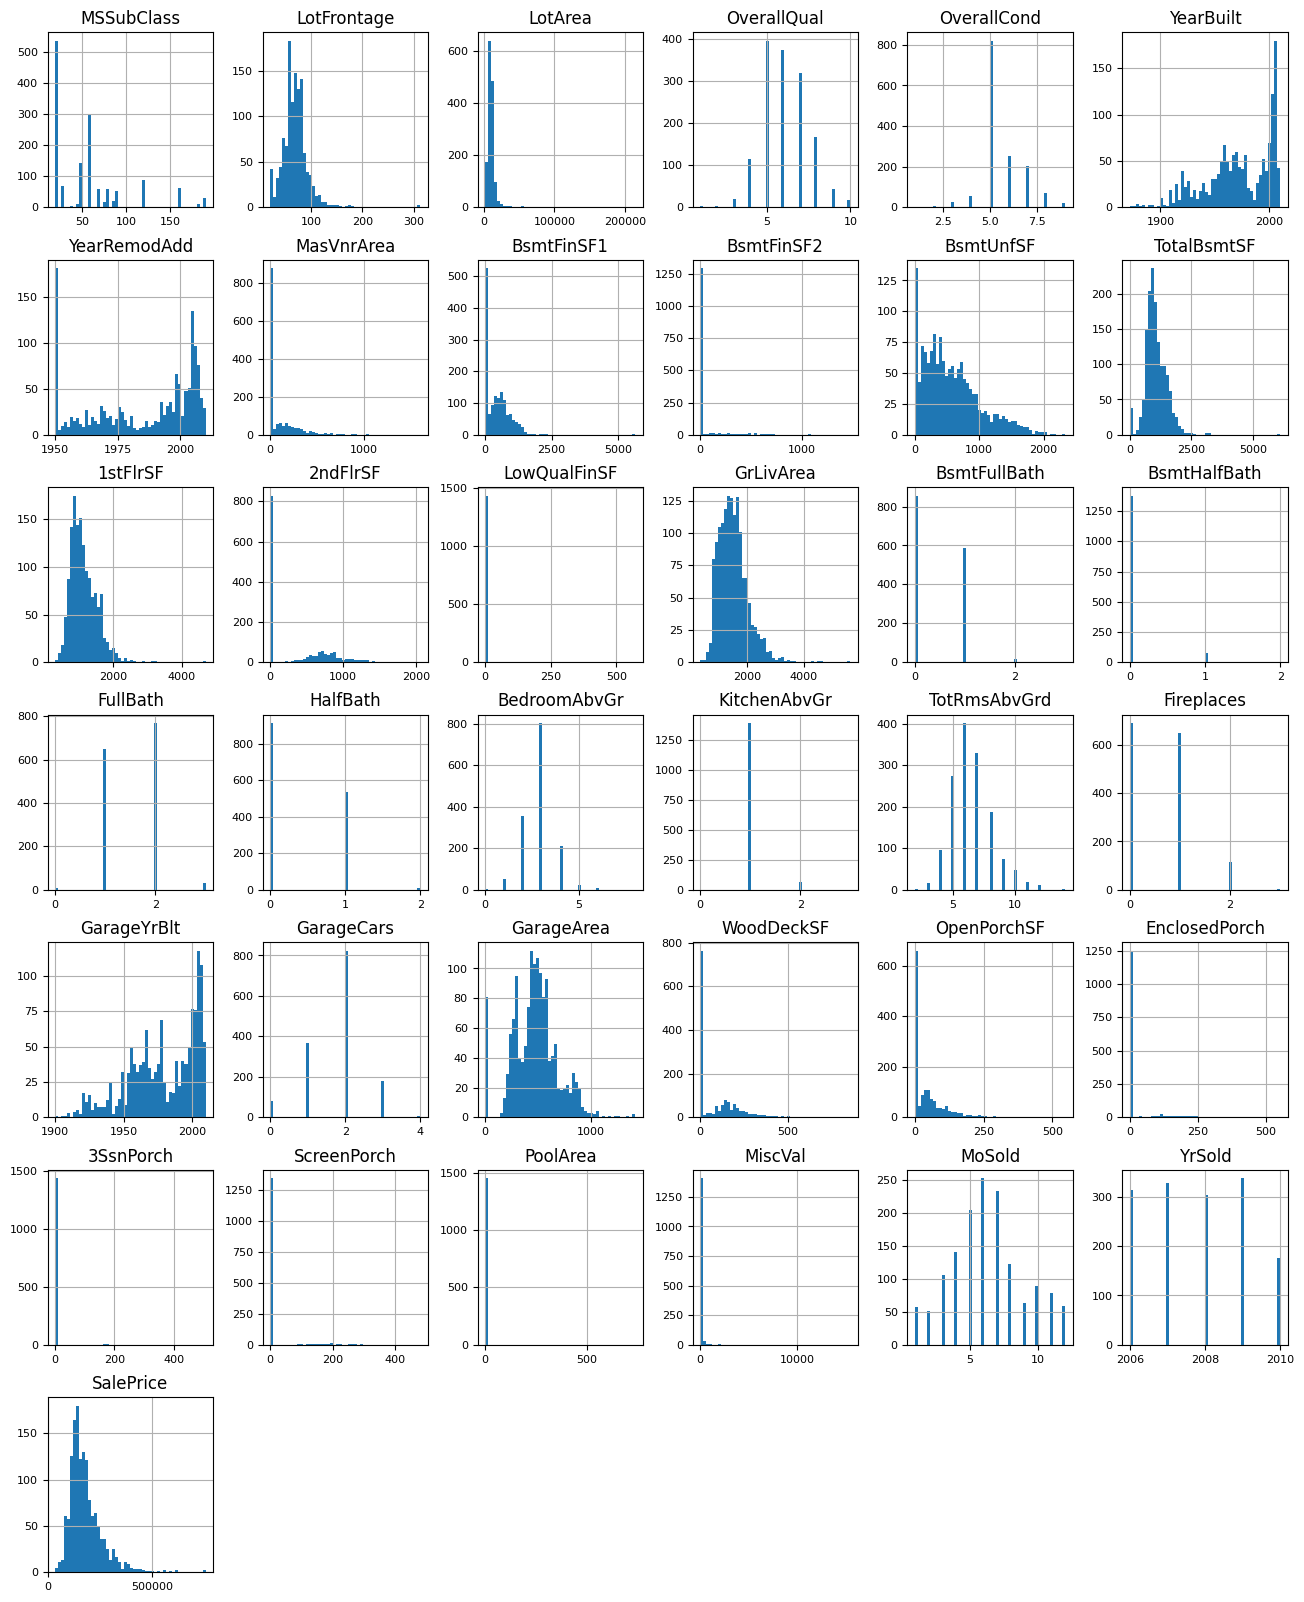

In [31]:
df_quant.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

In [32]:
df_qual = df_train.select_dtypes(include=['object', 'category'])
print("\nQualitative (Categorical) Columns:")
df_qual.head()


Qualitative (Categorical) Columns:


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


## Data Preprocessing

In [33]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

null values: <br>
LotFrontage, Alley, MasVnrType, MasVnrArea, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, Electrical, FireplaceQu,GarageType, GarageYrBlt, GarageFinish, GarageQual, GarageCond, PoolQC, Fence, MiscFeature

In [34]:
class HousingPreprocessor:
    def __init__(self):
        # Keep informative categorical columns; don't drop them
        self.drop_cols = []

        # Categorical columns where NA means absence of the feature
        self.none_cols = [
            "PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType",
            "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
            "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond"
        ]

        # Numeric cols where NA should be treated as 0 (absence)
        self.zero_cols = [
            "MasVnrArea",
            "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
            "BsmtFullBath", "BsmtHalfBath", "GarageYrBlt", "GarageCars", "GarageArea"
        ]

    def transform(self, df):
        df = df.drop(columns=[col for col in self.drop_cols if col in df.columns], errors='ignore')

        # Fill categorical NAs with explicit 'None' category
        for col in self.none_cols:
            if col in df.columns:
                df[col] = df[col].fillna("None")

        # Fill numeric NAs with 0 where appropriate
        for col in self.zero_cols:
            if col in df.columns:
                df[col] = df[col].fillna(0)

        # Neighborhood-median imputation for LotFrontage
        if "LotFrontage" in df.columns and "Neighborhood" in df.columns:
            df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

        # Basic type consistency for categoricals
        for col in df.select_dtypes(include='object').columns:
            df[col] = df[col].astype(str)

        # One-hot encode categoricals
        df = pd.get_dummies(df, drop_first=True)

        # Ensure bools become ints
        for col in df.select_dtypes(include='bool').columns:
            df[col] = df[col].astype('int32')

        return df

In [35]:
preprocessor = HousingPreprocessor()
df_train = preprocessor.transform(df_train)

## Feature Engineering

In [36]:
def feature_engineering(df):
    # Total bathrooms (full + 0.5*half) including basement
    if set(["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"]).issubset(df.columns):
        df["TotalBaths"] = (
            df["FullBath"].fillna(0)
            + 0.5 * df["HalfBath"].fillna(0)
            + df["BsmtFullBath"].fillna(0)
            + 0.5 * df["BsmtHalfBath"].fillna(0)
        )

    # Total square footage (basement + floors)
    if set(["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"]).issubset(df.columns):
        df["TotalSF"] = df["TotalBsmtSF"].fillna(0) + df["1stFlrSF"].fillna(0) + df["2ndFlrSF"].fillna(0)

    # Porches
    for col in ["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"]:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    if set(["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"]).issubset(df.columns):
        df["TotalPorchSF"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]

    # Binary presence flags
    if "PoolArea" in df.columns:
        df["HasPool"] = (df["PoolArea"].fillna(0) > 0).astype("int32")
    if "GarageArea" in df.columns:
        df["HasGarage"] = (df["GarageArea"].fillna(0) > 0).astype("int32")
    if "Fireplaces" in df.columns:
        df["HasFireplace"] = (df["Fireplaces"].fillna(0) > 0).astype("int32")
    if "TotalPorchSF" in df.columns:
        df["HasPorch"] = (df["TotalPorchSF"].fillna(0) > 0).astype("int32")

    # Age-related features
    for col in ["YearBuilt", "YearRemodAdd", "YrSold"]:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())
    if set(["YrSold", "YearBuilt"]).issubset(df.columns):
        df["HouseAge"] = (df["YrSold"] - df["YearBuilt"]).clip(lower=0)
    if set(["YrSold", "YearRemodAdd"]).issubset(df.columns):
        df["RemodelAge"] = (df["YrSold"] - df["YearRemodAdd"]).clip(lower=0)
    if set(["YearBuilt", "YearRemodAdd"]).issubset(df.columns):
        df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype("int32")

    # Simple interaction: quality-weighted living area
    if set(["OverallQual", "GrLivArea"]).issubset(df.columns):
        df["QualXGrLivArea"] = df["OverallQual"].fillna(0) * df["GrLivArea"].fillna(0)

    return df

df_train = feature_engineering(df_train)
df_train.head()

C:\Users\user\AppData\Local\Temp\ipykernel_20820\3098653882.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["TotalBaths"] = (
C:\Users\user\AppData\Local\Temp\ipykernel_20820\3098653882.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["TotalSF"] = df["TotalBsmtSF"].fillna(0) + df["1stFlrSF"].fillna(0) + df["2ndFlrSF"].fillna(0)
C:\Users\user\AppData\Local\Temp\ipykernel_20820\3098653882.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,TotalSF,TotalPorchSF,HasPool,HasGarage,HasFireplace,HasPorch,HouseAge,RemodelAge,IsRemodeled,QualXGrLivArea
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,2566,61,0,1,0,1,5,5,0,11970
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,2524,0,0,1,1,0,31,31,0,7572
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,2706,42,0,1,1,1,7,6,1,12502
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,2473,307,0,1,1,1,91,36,1,12019
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,3343,84,0,1,1,1,8,8,0,17584


## Data Splitting (Train and Validation)

In [37]:
def split_dataset(dataset, test_ratio=0.30):
  test_indices = np.random.rand(len(dataset)) < test_ratio
  return dataset[~test_indices], dataset[test_indices]

train_ds_pd, valid_ds_pd = split_dataset(df_train)
print("{} examples in training, {} examples in validation.".format(
    len(train_ds_pd), len(valid_ds_pd)))

1020 examples in training, 440 examples in validation.


## Model Training

In [38]:
label = 'SalePrice'

# Prepare features/target for train and validation sets
y_train = train_ds_pd[label]
X_train = train_ds_pd.drop(columns=[label])

y_valid = valid_ds_pd[label]
X_valid = valid_ds_pd.drop(columns=[label])

print(f"X_train shape: {X_train.shape} | X_valid shape: {X_valid.shape}")

X_train shape: (1020, 271) | X_valid shape: (440, 271)


In [39]:
# No model listing needed for scikit-learn; this cell can be used to show feature count
X_train.shape, X_valid.shape

((1020, 271), (440, 271))

### 1. Random Forest (scikit-learn)

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    oob_score=True,
    bootstrap=True
)
rf

,n_estimators,400
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [41]:
rf.fit(X_train, y_train)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)


,n_estimators,400
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [42]:
# Out-of-bag score (R^2 on OOB samples)
print(f"OOB R2: {rf.oob_score_:.4f}")

OOB R2: 0.8555


In [43]:
# Evaluation on validation split
pred_valid = rf.predict(X_valid)
mse = mean_squared_error(y_valid, pred_valid)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_valid, pred_valid)
r2 = r2_score(y_valid, pred_valid)
print(f"RMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR2: {r2:.4f}")

RMSE: 28527.4275
MAE: 15902.8340
R2: 0.8437


In [44]:
# Top 20 feature importances
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(20)

QualXGrLivArea    0.607226
OverallQual       0.093178
TotalSF           0.052245
TotalBsmtSF       0.027379
BsmtFinSF1        0.026526
2ndFlrSF          0.026220
HouseAge          0.011624
GarageCars        0.011566
YearBuilt         0.009739
LotArea           0.007997
GarageArea        0.007789
1stFlrSF          0.005675
YearRemodAdd      0.005654
RemodelAge        0.005629
MasVnrArea        0.005228
GrLivArea         0.005102
LotFrontage       0.004927
BsmtUnfSF         0.004754
OverallCond       0.004123
GarageYrBlt       0.004004
dtype: float64

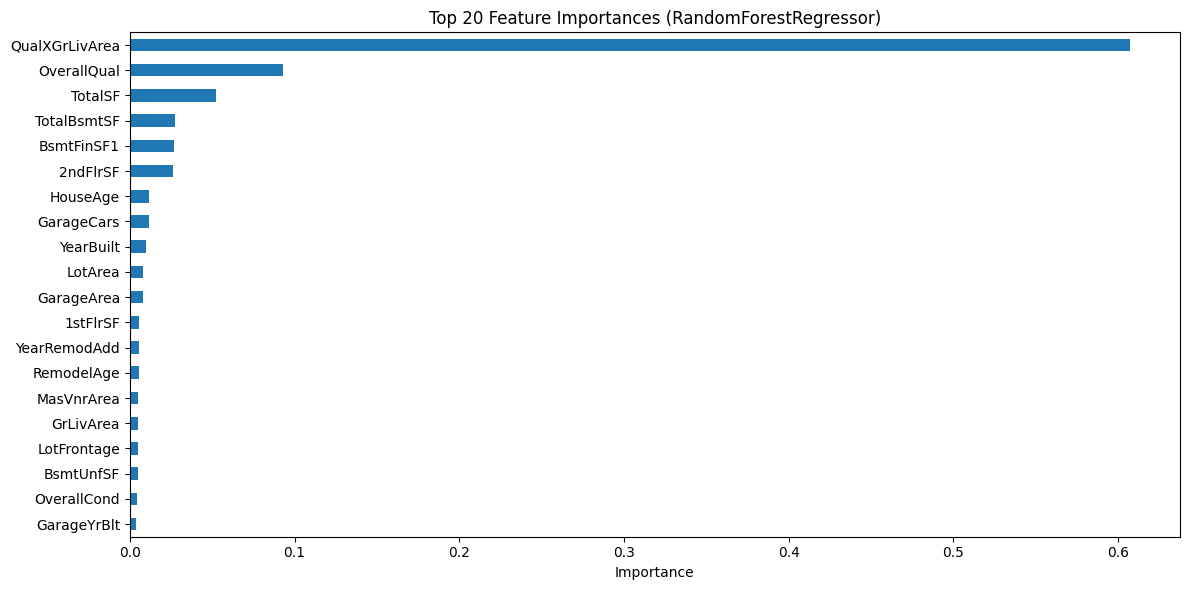

In [45]:
# Plot feature importances
plt.figure(figsize=(12, 6))
importances.head(20)[::-1].plot(kind='barh')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances (RandomForestRegressor)')
plt.tight_layout()
plt.show()

## 2. XGBoost

In [46]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50
)

[0]	validation_0-rmse:69859.37486
[50]	validation_0-rmse:28725.86265
[50]	validation_0-rmse:28725.86265
[100]	validation_0-rmse:27433.12119
[100]	validation_0-rmse:27433.12119
[150]	validation_0-rmse:26776.75261
[150]	validation_0-rmse:26776.75261
[200]	validation_0-rmse:26461.90883
[200]	validation_0-rmse:26461.90883
[250]	validation_0-rmse:26304.73610
[250]	validation_0-rmse:26304.73610
[300]	validation_0-rmse:26217.51958
[300]	validation_0-rmse:26217.51958
[350]	validation_0-rmse:26147.98677
[350]	validation_0-rmse:26147.98677
[400]	validation_0-rmse:26121.20546
[400]	validation_0-rmse:26121.20546
[450]	validation_0-rmse:26138.70693
[450]	validation_0-rmse:26138.70693
[457]	validation_0-rmse:26134.26425
[457]	validation_0-rmse:26134.26425


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


In [47]:
# XGBoost evaluation
pred_xgb = xgb.predict(X_valid)
mse_xgb = mean_squared_error(y_valid, pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_valid, pred_xgb)
r2_xgb = r2_score(y_valid, pred_xgb)
print(f"XGBoost Results:")
print(f"RMSE: {rmse_xgb:.4f}\nMAE: {mae_xgb:.4f}\nR2: {r2_xgb:.4f}")

XGBoost Results:
RMSE: 26113.3750
MAE: 14469.5684
R2: 0.8691


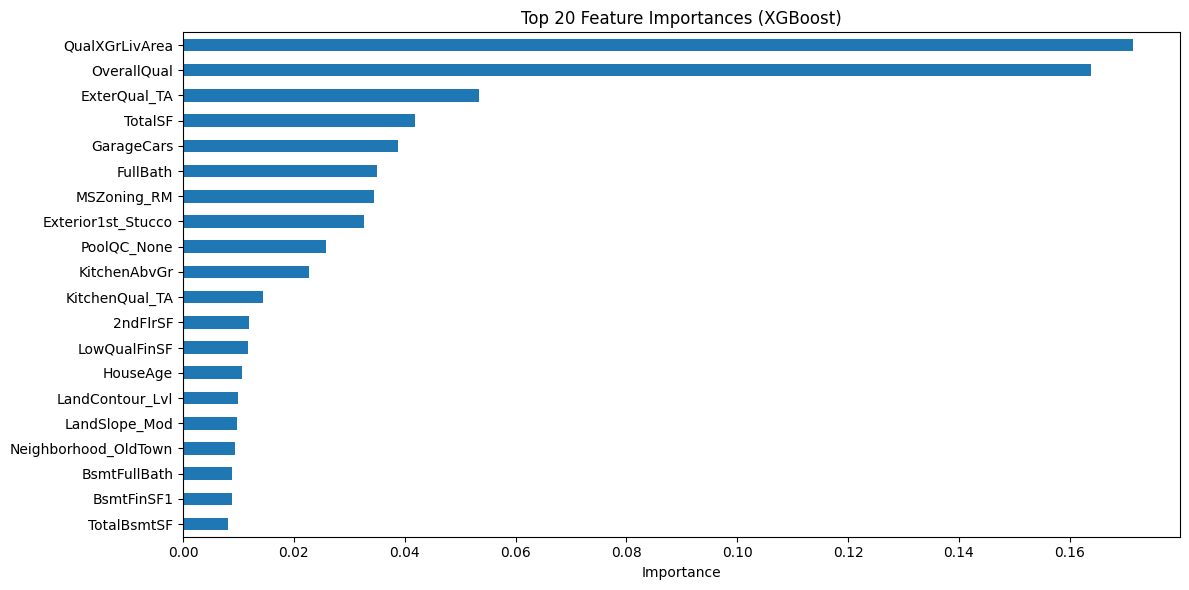

In [48]:
# XGBoost feature importances
xgb_importances = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
xgb_importances.head(20)[::-1].plot(kind='barh')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

## 3. LightGBM

In [49]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

lgbm = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[early_stopping(stopping_rounds=50, verbose=False), log_evaluation(period=50)]
)

[50]	valid_0's l2: 7.69203e+08
[100]	valid_0's l2: 7.19554e+08


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [50]:
# LightGBM evaluation
pred_lgbm = lgbm.predict(X_valid)
mse_lgbm = mean_squared_error(y_valid, pred_lgbm)
rmse_lgbm = np.sqrt(mse_lgbm)
mae_lgbm = mean_absolute_error(y_valid, pred_lgbm)
r2_lgbm = r2_score(y_valid, pred_lgbm)
print(f"LightGBM Results:")
print(f"RMSE: {rmse_lgbm:.4f}\nMAE: {mae_lgbm:.4f}\nR2: {r2_lgbm:.4f}")

LightGBM Results:
RMSE: 26619.1593
MAE: 15355.4348
R2: 0.8640


## 4. Gradient Boosting (sklearn)

In [51]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,500
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [52]:
# Gradient Boosting evaluation
pred_gbr = gbr.predict(X_valid)
mse_gbr = mean_squared_error(y_valid, pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mae_gbr = mean_absolute_error(y_valid, pred_gbr)
r2_gbr = r2_score(y_valid, pred_gbr)
print(f"Gradient Boosting Results:")
print(f"RMSE: {rmse_gbr:.4f}\nMAE: {mae_gbr:.4f}\nR2: {r2_gbr:.4f}")

Gradient Boosting Results:
RMSE: 26316.8341
MAE: 14479.7975
R2: 0.8670


## Model Comparison


MODEL COMPARISON (sorted by RMSE - lower is better)
            Model         RMSE          MAE       R2
          XGBoost 26113.374964 14469.568359 0.869074
Gradient Boosting 26316.834109 14479.797525 0.867026
         LightGBM 26619.159269 15355.434783 0.863953
    Random Forest 28527.427483 15902.833955 0.843748


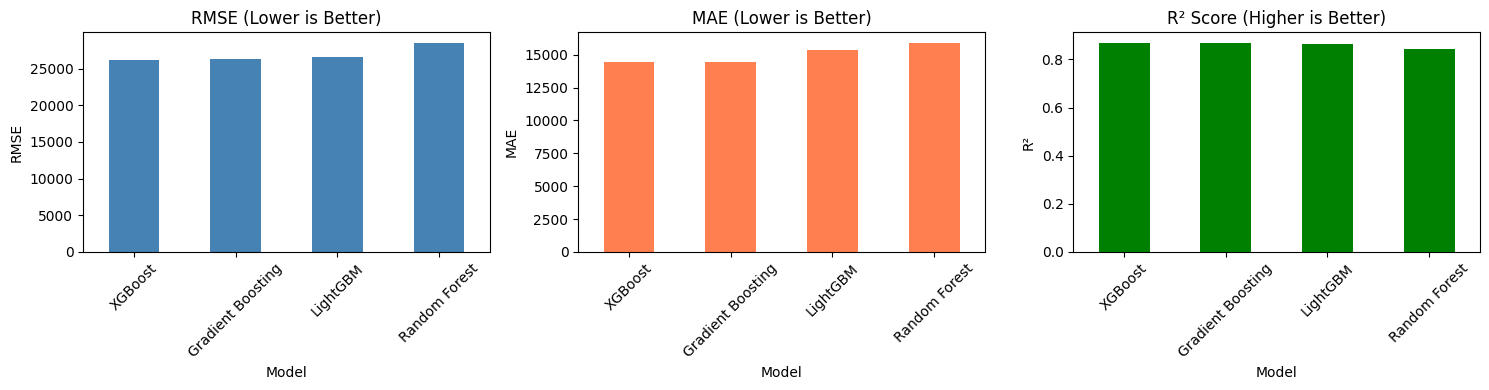

In [53]:
# Compare all models
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting'],
    'RMSE': [rmse, rmse_xgb, rmse_lgbm, rmse_gbr],
    'MAE': [mae, mae_xgb, mae_lgbm, mae_gbr],
    'R2': [r2, r2_xgb, r2_lgbm, r2_gbr]
})

comparison_df = comparison_df.sort_values('RMSE')
print("\n" + "="*60)
print("MODEL COMPARISON (sorted by RMSE - lower is better)")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

comparison_df.plot(x='Model', y='RMSE', kind='bar', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('RMSE (Lower is Better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)

comparison_df.plot(x='Model', y='MAE', kind='bar', ax=axes[1], legend=False, color='coral')
axes[1].set_title('MAE (Lower is Better)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

comparison_df.plot(x='Model', y='R2', kind='bar', ax=axes[2], legend=False, color='green')
axes[2].set_title('R² Score (Higher is Better)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Stacking Ensemble

In [54]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

# Create stacking ensemble with the best performing models
estimators = [
    ('rf', RandomForestRegressor(n_estimators=400, max_depth=None, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1)),
    ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)),
    ('gbr', GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42))
]

# Use Ridge regression as the final estimator (meta-learner)
stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

print("Training stacking ensemble (this may take a few minutes)...")
stacking.fit(X_train, y_train)

Training stacking ensemble (this may take a few minutes)...


,estimators,"[('rf', ...), ('xgb', ...), ...]"
,final_estimator,Ridge()
,cv,5
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,400
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [55]:
# Stacking Ensemble evaluation
pred_stack = stacking.predict(X_valid)
mse_stack = mean_squared_error(y_valid, pred_stack)
rmse_stack = np.sqrt(mse_stack)
mae_stack = mean_absolute_error(y_valid, pred_stack)
r2_stack = r2_score(y_valid, pred_stack)
print(f"\nStacking Ensemble Results:")
print(f"RMSE: {rmse_stack:.4f}\nMAE: {mae_stack:.4f}\nR2: {r2_stack:.4f}")

# Final comparison with stacking
final_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting', 'Stacking Ensemble'],
    'RMSE': [rmse, rmse_xgb, rmse_lgbm, rmse_gbr, rmse_stack],
    'MAE': [mae, mae_xgb, mae_lgbm, mae_gbr, mae_stack],
    'R2': [r2, r2_xgb, r2_lgbm, r2_gbr, r2_stack]
})

final_comparison = final_comparison.sort_values('RMSE')
print("\n" + "="*70)
print("FINAL MODEL COMPARISON (including Stacking Ensemble)")
print("="*70)
print(final_comparison.to_string(index=False))
print("="*70)
print(f"\nBest Model: {final_comparison.iloc[0]['Model']}")
print(f"Best RMSE: {final_comparison.iloc[0]['RMSE']:.4f}")


Stacking Ensemble Results:
RMSE: 25952.5269
MAE: 14936.8171
R2: 0.8707

FINAL MODEL COMPARISON (including Stacking Ensemble)
            Model         RMSE          MAE       R2
Stacking Ensemble 25952.526948 14936.817130 0.870682
          XGBoost 26113.374964 14469.568359 0.869074
Gradient Boosting 26316.834109 14479.797525 0.867026
         LightGBM 26619.159269 15355.434783 0.863953
    Random Forest 28527.427483 15902.833955 0.843748

Best Model: Stacking Ensemble
Best RMSE: 25952.5269


## Submission - Best Model (XGBoost)

In [56]:
# Prepare test set and generate predictions using XGBoost (best model)
df_test = pd.read_csv("test.csv")
ids = df_test.pop('Id')

# Apply same preprocessing pipeline
df_test_proc = preprocessor.transform(df_test)
df_test_proc = feature_engineering(df_test_proc)

# Align columns to training features (handle missing/extra columns)
missing_cols = [c for c in X_train.columns if c not in df_test_proc.columns]
for c in missing_cols:
    df_test_proc[c] = 0
    
extra_cols = [c for c in df_test_proc.columns if c not in X_train.columns]
df_test_proc = df_test_proc.drop(columns=extra_cols)

# Ensure same column order as training
df_test_proc = df_test_proc[X_train.columns]

print(f"Test set shape: {df_test_proc.shape}")
print(f"Training set shape: {X_train.shape}")
print(f"Columns match: {list(df_test_proc.columns) == list(X_train.columns)}")

# Generate predictions with XGBoost (best model)
preds_xgb = xgb.predict(df_test_proc)

# Create submission DataFrame
submission = pd.DataFrame({
    'Id': ids,
    'SalePrice': preds_xgb
})

# Save to CSV
submission.to_csv('xgboost_submission.csv', index=False)
print(f"  Total predictions: {len(submission)}")
print(f"  Price range: ${submission['SalePrice'].min():.2f} - ${submission['SalePrice'].max():.2f}")
print(f"  Mean price: ${submission['SalePrice'].mean():.2f}")

submission.head(10)

Test set shape: (1459, 271)
Training set shape: (1020, 271)
Columns match: True
  Total predictions: 1459
  Price range: $50391.45 - $594942.06
  Mean price: $177926.50

Training set shape: (1020, 271)
Columns match: True
  Total predictions: 1459
  Price range: $50391.45 - $594942.06
  Mean price: $177926.50


C:\Users\user\AppData\Local\Temp\ipykernel_20820\3098653882.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["TotalBaths"] = (
C:\Users\user\AppData\Local\Temp\ipykernel_20820\3098653882.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["TotalSF"] = df["TotalBsmtSF"].fillna(0) + df["1stFlrSF"].fillna(0) + df["2ndFlrSF"].fillna(0)
C:\Users\user\AppData\Local\Temp\ipykernel_20820\3098653882.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which

,Id,SalePrice
0,1461,128055.250000
1,1462,185643.562500
2,1463,185837.953125
3,1464,195739.296875
4,1465,185780.484375
5,1466,174787.031250
6,1467,171444.375000
7,1468,169912.312500
8,1469,179659.859375
9,1470,137373.265625
